# Does Width or Depth Matter More in Multilayer Perceptrons?
## An Experimental Study of Performance and Generalisation


**GitHub Repository:** https://github.com/Vinaykumar3678/mlp-depth-vs-width-tutorial

## Aim
This tutorial investigates whether increasing the **width** or the **depth** of a multilayer perceptron (MLP) has a greater effect on classification performance and generalisation.

## Research Question
Does increasing the number of hidden layers or the number of neurons per layer improve MLP performance and generalisation more?

## Hypothesis
Increasing width should improve performance by giving the network more capacity, while increasing depth may help the model learn more complex patterns. However, deeper networks may also become harder to train and may overfit more easily.

## Introduction

Multilayer Perceptrons (MLPs) are a class of feedforward neural networks widely used for classification and regression tasks. They consist of an input layer, one or more hidden layers, and an output layer. Each hidden layer is composed of neurons that apply a weighted transformation followed by a nonlinear activation function.

Two important architectural properties of MLPs are **width** and **depth**. Width refers to the number of neurons within a hidden layer, while depth refers to the number of hidden layers in the network. Both factors influence the model’s ability to learn patterns from data.

Increasing the width of a network can provide greater capacity to represent complex relationships, while increasing depth allows the model to learn hierarchical and more abstract features. However, increasing model size can also lead to challenges such as overfitting and increased computational cost.

Understanding how width and depth affect performance and generalisation is important for designing effective neural networks. This tutorial investigates these factors experimentally using different MLP architectures.

In [24]:
# Core libraries
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Why Fashion-MNIST?

Fashion-MNIST is a dataset of 28×28 grayscale images of clothing items such as shirts, shoes and bags. It is more challenging than very simple datasets such as Iris, but still small enough to train quickly in a tutorial.

This makes it suitable for comparing different MLP architectures fairly.

In [25]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Class names for Fashion-MNIST
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

## Load and Prepare the Data

The data is normalised to the range `[0, 1]` so that training is more stable.  
The training set is also split into a smaller training set and a validation set.

- **Training set**: used to fit the model  
- **Validation set**: used to monitor learning during training  
- **Test set**: used only for final evaluation

In [26]:
# Load Fashion-MNIST
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

# Normalise pixel values
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Create validation split from training data
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

# One-hot encode labels for Keras
y_train_cat = to_categorical(y_train, num_classes=10)
y_val_cat = to_categorical(y_val, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Training set shape:", x_train.shape)
print("Validation set shape:", x_val.shape)
print("Test set shape:", x_test.shape)

Training set shape: (48000, 28, 28)
Validation set shape: (12000, 28, 28)
Test set shape: (10000, 28, 28)


## Visualising Sample Images

Before training the models, it is useful to inspect a few examples from the dataset.

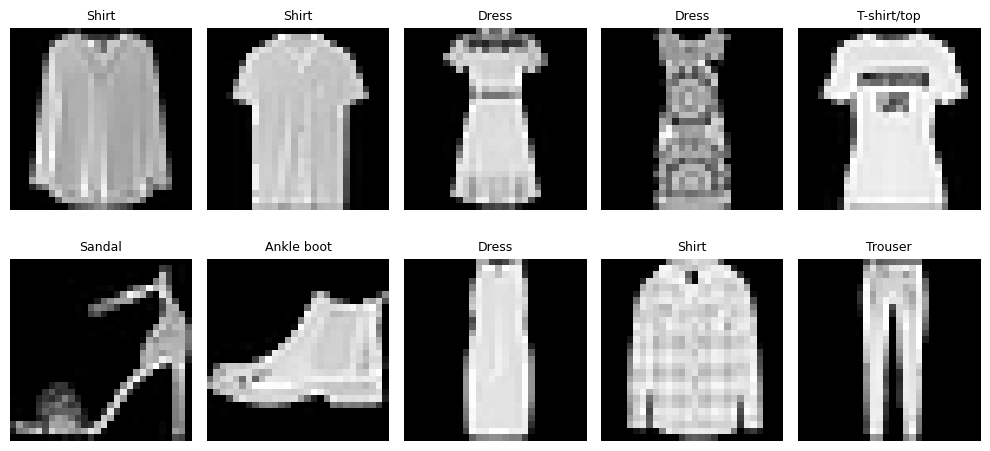

In [27]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Experimental Design

To make the comparison fair, the following settings are kept constant:

- Optimiser: Adam
- Activation function: ReLU
- Batch size: 64
- Epochs: 20
- Output layer: Softmax
- Dataset and train/validation/test split: identical for all models

Two groups of models are compared:

### Depth-focused models
These vary the **number of hidden layers** while keeping the number of neurons per layer fixed.

### Width-focused models
These vary the **number of neurons per layer** while keeping the number of hidden layers fixed.

In [28]:
EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 0.001

# Model configurations
depth_configs = {
    "Depth-1 (128)": [128],
    "Depth-3 (128)": [128, 128, 128],
    "Depth-5 (128)": [128, 128, 128, 128, 128],
}

width_configs = {
    "Width-32 (2 layers)": [32, 32],
    "Width-128 (2 layers)": [128, 128],
    "Width-512 (2 layers)": [512, 512],
}

all_configs = {}
all_configs.update(depth_configs)
all_configs.update(width_configs)

all_configs

{'Depth-1 (128)': [128],
 'Depth-3 (128)': [128, 128, 128],
 'Depth-5 (128)': [128, 128, 128, 128, 128],
 'Width-32 (2 layers)': [32, 32],
 'Width-128 (2 layers)': [128, 128],
 'Width-512 (2 layers)': [512, 512]}

## Building the MLP

Each model is a feedforward neural network with:

1. A flatten layer to convert a 28×28 image into a vector
2. One or more hidden dense layers with ReLU activation
3. A final softmax layer with 10 output classes

In [29]:
def build_mlp(hidden_layers, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(28, 28)))
    model.add(Flatten())

    for units in hidden_layers:
        model.add(Dense(units, activation="relu"))

    model.add(Dense(10, activation="softmax"))

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

## Training the Models

The next cell trains every model and stores:

- training history
- final validation performance
- final test performance
- training time
- generalisation gap

The **generalisation gap** is defined here as:

`training accuracy - test accuracy`

A larger gap suggests the model may be overfitting.

In [30]:
results = {}
histories = {}

for model_name, hidden_layers in all_configs.items():
    print(f"Training {model_name} with layers {hidden_layers}")

    model = build_mlp(hidden_layers, learning_rate=LEARNING_RATE)

    start_time = time.time()

    history = model.fit(
        x_train,
        y_train_cat,
        validation_data=(x_val, y_val_cat),
        epochs=10,
        batch_size=BATCH_SIZE,
        verbose=0
    )

    training_time = time.time() - start_time

    train_loss, train_acc = model.evaluate(x_train, y_train_cat, verbose=0)
    val_loss, val_acc = model.evaluate(x_val, y_val_cat, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

    generalisation_gap = train_acc - test_acc

    results[model_name] = {
        "hidden_layers": hidden_layers,
        "num_layers": len(hidden_layers),
        "neurons_per_layer": hidden_layers[0] if len(set(hidden_layers)) == 1 else str(hidden_layers),
        "train_accuracy": train_acc,
        "val_accuracy": val_acc,
        "test_accuracy": test_acc,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "test_loss": test_loss,
        "training_time_sec": training_time,
        "generalisation_gap": generalisation_gap,
        "model": model
    }

    histories[model_name] = history.history

print("Training complete.")

Training Depth-1 (128) with layers [128]
Training Depth-3 (128) with layers [128, 128, 128]
Training Depth-5 (128) with layers [128, 128, 128, 128, 128]
Training Width-32 (2 layers) with layers [32, 32]
Training Width-128 (2 layers) with layers [128, 128]
Training Width-512 (2 layers) with layers [512, 512]
Training complete.


## Summary Table of Results

This table provides an overall comparison of all architectures.

In [31]:
results_df = pd.DataFrame(results).T.drop(columns=["model"])
results_df = results_df.sort_values(by="test_accuracy", ascending=False)

# Round numeric columns for readability
for col in ["train_accuracy", "val_accuracy", "test_accuracy",
            "train_loss", "val_loss", "test_loss",
            "training_time_sec", "generalisation_gap"]:
    results_df[col] = results_df[col].astype(float).round(4)

results_df

,hidden_layers,num_layers,neurons_per_layer,train_accuracy,val_accuracy,test_accuracy,train_loss,val_loss,test_loss,training_time_sec,generalisation_gap
Width-512 (2 layers),"[512, 512]",2,512,0.9164,0.8875,0.8792,0.2188,0.3471,0.3743,45.2155,0.0372
Depth-5 (128),"[128, 128, 128, 128, 128]",5,128,0.9081,0.8848,0.8775,0.2446,0.3413,0.3770,24.9843,0.0306
Depth-3 (128),"[128, 128, 128]",3,128,0.9112,0.8898,0.8768,0.2350,0.3417,0.3795,21.0534,0.0344
Width-128 (2 layers),"[128, 128]",2,128,0.9110,0.8844,0.8751,0.2368,0.3348,0.3680,17.8923,0.0359
Depth-1 (128),[128],1,128,0.9075,0.8877,0.8731,0.2473,0.3229,0.3528,17.6286,0.0344
Width-32 (2 layers),"[32, 32]",2,32,0.8900,0.8752,0.8647,0.2995,0.3526,0.3825,18.1609,0.0253


## Plot 1: Accuracy Curves for Depth Models

These plots show how training and validation accuracy change over time as depth increases.

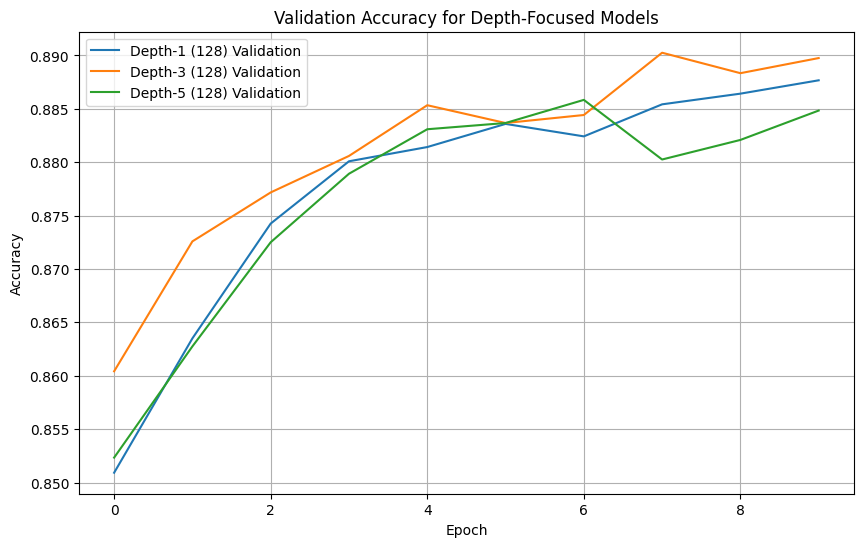

In [33]:
plt.figure(figsize=(10, 6))

for model_name in depth_configs.keys():
    plt.plot(histories[model_name]["val_accuracy"], label=f"{model_name} Validation")

plt.title("Validation Accuracy for Depth-Focused Models")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Plot 2: Loss Curves for Depth Models

This plot helps show whether deeper models learn smoothly or become unstable.

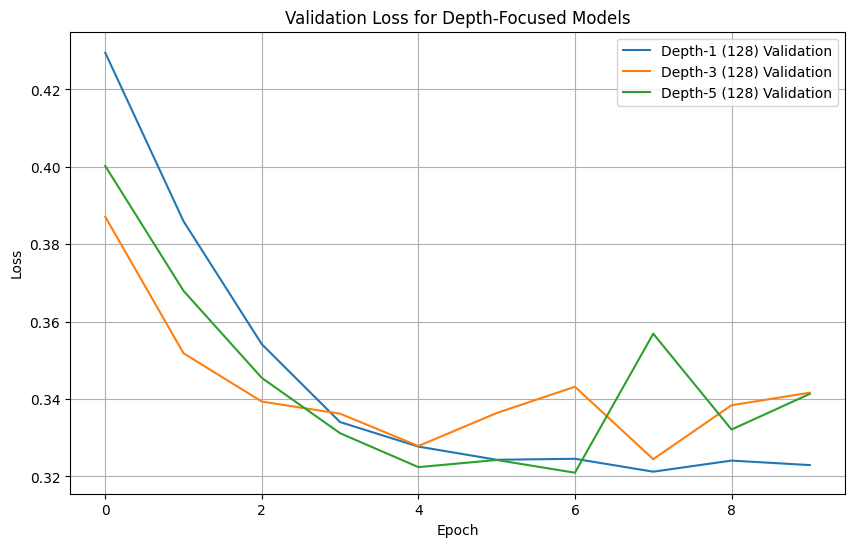

In [34]:
plt.figure(figsize=(10, 6))

for model_name in depth_configs.keys():
    plt.plot(histories[model_name]["val_loss"], label=f"{model_name} Validation")

plt.title("Validation Loss for Depth-Focused Models")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Plot 3: Accuracy Curves for Width Models

These plots show how validation accuracy changes when the network becomes wider.

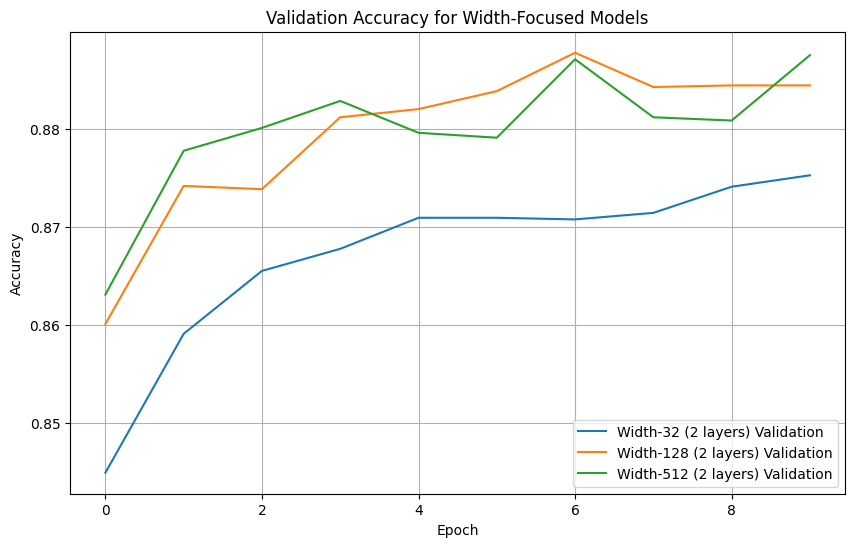

In [35]:
plt.figure(figsize=(10, 6))

for model_name in width_configs.keys():
    plt.plot(histories[model_name]["val_accuracy"], label=f"{model_name} Validation")

plt.title("Validation Accuracy for Width-Focused Models")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Plot 4: Loss Curves for Width Models

This plot shows whether wider models converge more effectively than narrower ones.

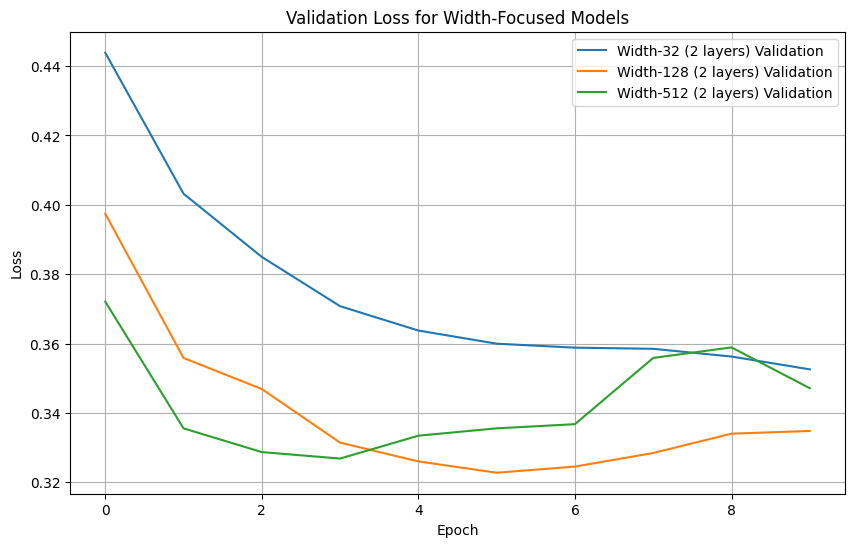

In [36]:
plt.figure(figsize=(10, 6))

for model_name in width_configs.keys():
    plt.plot(histories[model_name]["val_loss"], label=f"{model_name} Validation")

plt.title("Validation Loss for Width-Focused Models")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Plot 5: Final Test Accuracy of All Models

This is one of the most important plots in the tutorial because it directly compares final performance.

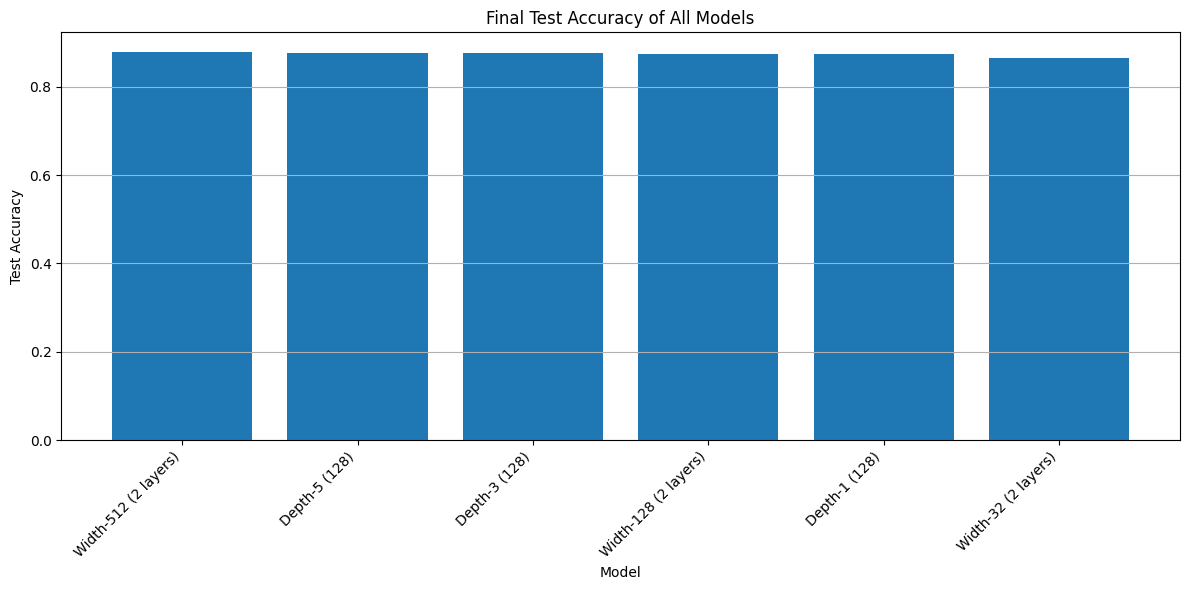

In [37]:
plot_df = results_df.reset_index().rename(columns={"index": "Model"})

plt.figure(figsize=(12, 6))
plt.bar(plot_df["Model"], plot_df["test_accuracy"])
plt.title("Final Test Accuracy of All Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Plot 6: Generalisation Gap of All Models

A smaller generalisation gap usually indicates better ability to perform on unseen data.

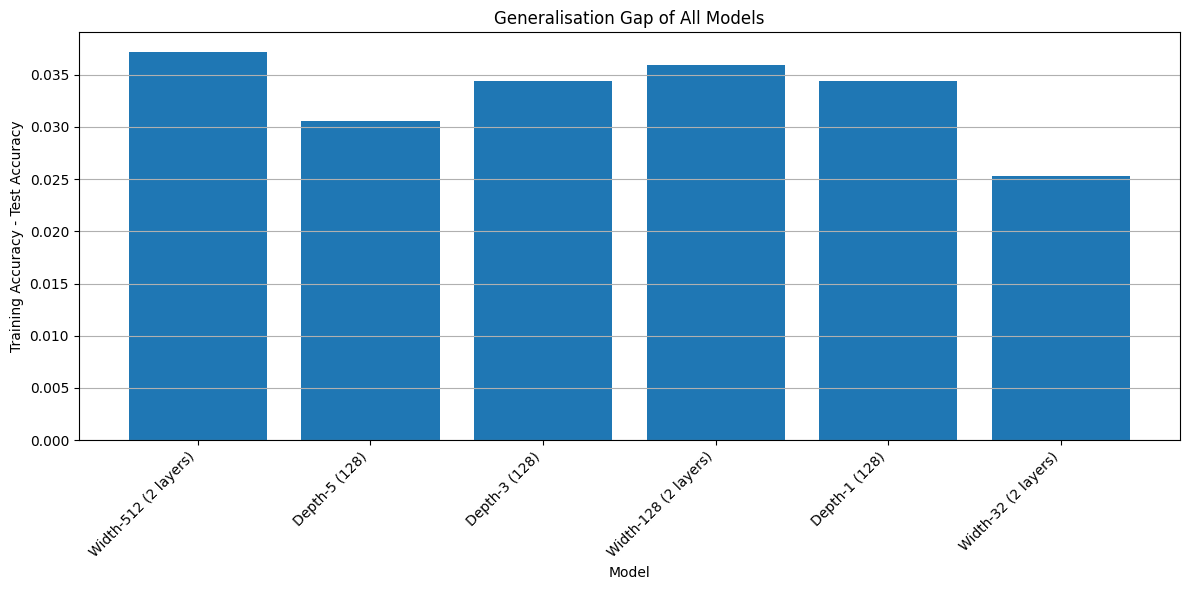

In [38]:
plt.figure(figsize=(12, 6))
plt.bar(plot_df["Model"], plot_df["generalisation_gap"])
plt.title("Generalisation Gap of All Models")
plt.xlabel("Model")
plt.ylabel("Training Accuracy - Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Plot 7: Training Time of All Models

This plot compares computational cost. A model may achieve slightly better accuracy, but if it takes much longer to train, the practical trade-off should be discussed.

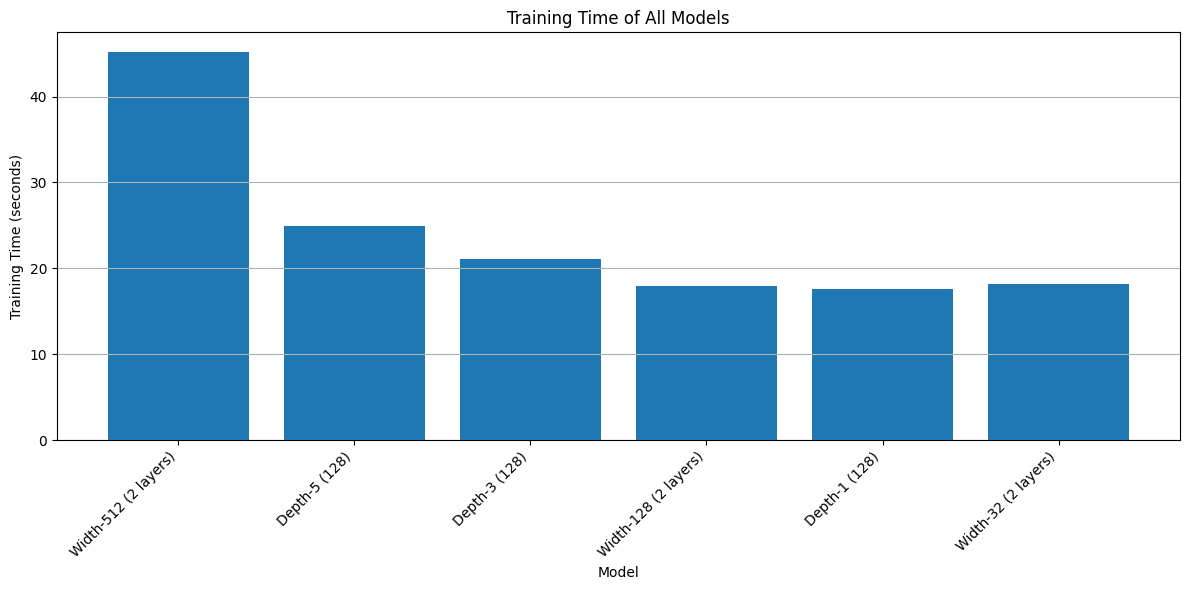

In [39]:
plt.figure(figsize=(12, 6))
plt.bar(plot_df["Model"], plot_df["training_time_sec"])
plt.title("Training Time of All Models")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Plot 8: Depth vs Test Accuracy

This plot isolates the effect of increasing depth while holding layer width constant at 128 neurons.

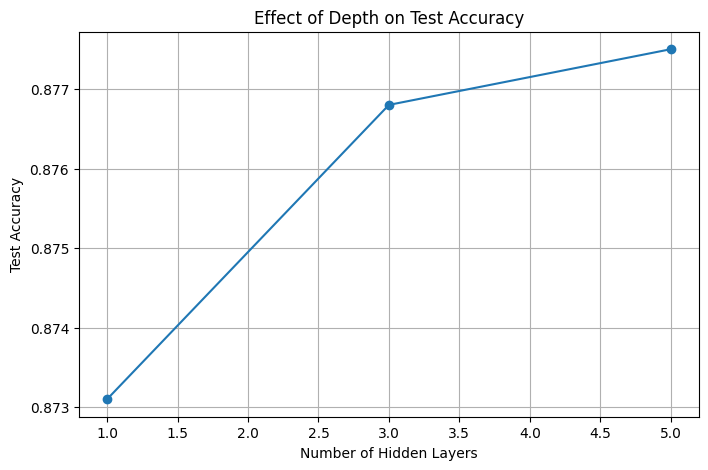

In [40]:
depth_plot_data = []
for model_name in depth_configs.keys():
    depth_plot_data.append({
        "Model": model_name,
        "Depth": len(results[model_name]["hidden_layers"]),
        "Test Accuracy": results[model_name]["test_accuracy"]
    })

depth_plot_df = pd.DataFrame(depth_plot_data).sort_values("Depth")

plt.figure(figsize=(8, 5))
plt.plot(depth_plot_df["Depth"], depth_plot_df["Test Accuracy"], marker="o")
plt.title("Effect of Depth on Test Accuracy")
plt.xlabel("Number of Hidden Layers")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()

## Plot 9: Width vs Test Accuracy

This plot isolates the effect of increasing width while holding depth constant at 2 hidden layers.

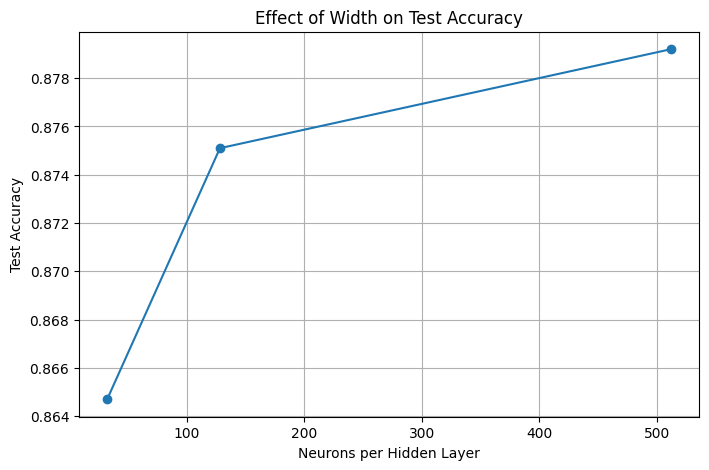

In [41]:
width_plot_data = []
for model_name in width_configs.keys():
    width_plot_data.append({
        "Model": model_name,
        "Width": results[model_name]["hidden_layers"][0],
        "Test Accuracy": results[model_name]["test_accuracy"]
    })

width_plot_df = pd.DataFrame(width_plot_data).sort_values("Width")

plt.figure(figsize=(8, 5))
plt.plot(width_plot_df["Width"], width_plot_df["Test Accuracy"], marker="o")
plt.title("Effect of Width on Test Accuracy")
plt.xlabel("Neurons per Hidden Layer")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()

## Best Model Analysis

To understand the strongest model in more detail, the next cell prints a classification report and confusion matrix.

In [42]:
best_model_name = results_df.index[0]
best_model = results[best_model_name]["model"]

print("Best model:", best_model_name)

y_pred_probs = best_model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Best model: Width-512 (2 layers)

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.85      0.84      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.74      0.84      0.79      1000
       Dress       0.92      0.86      0.89      1000
        Coat       0.81      0.76      0.78      1000
      Sandal       0.96      0.96      0.96      1000
       Shirt       0.69      0.68      0.69      1000
     Sneaker       0.91      0.97      0.94      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.98      0.92      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## Confusion Matrix

The confusion matrix shows which classes are most commonly confused by the best model.

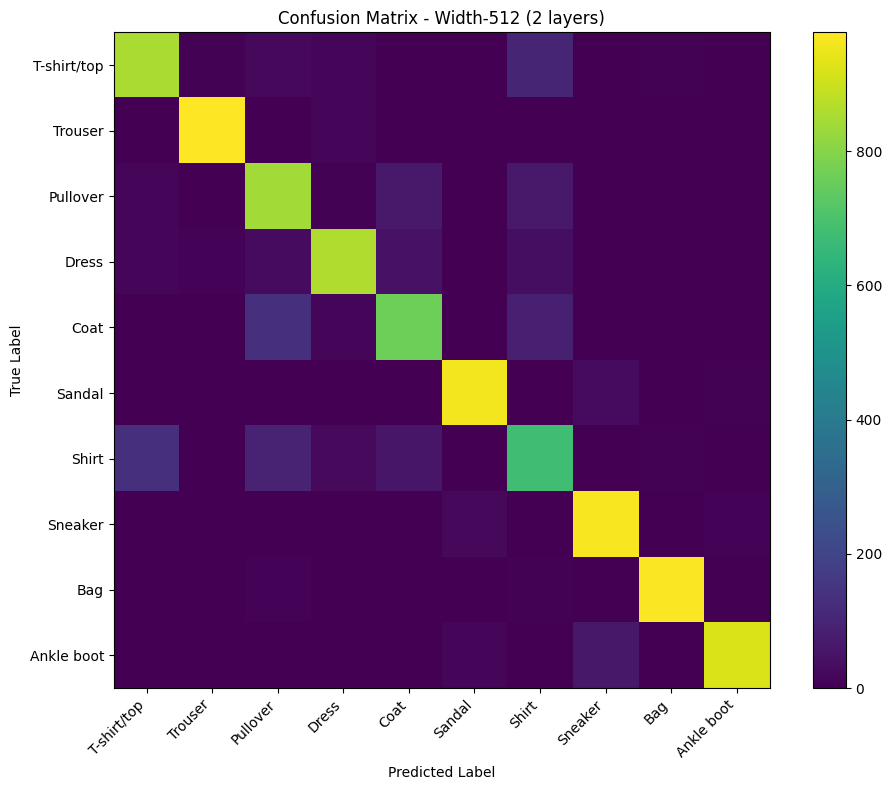

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Training vs Validation Accuracy (Best Model)

This plot compares training and validation accuracy over epochs for the best model.

Both curves increase steadily and remain close to each other, indicating good learning and minimal overfitting.

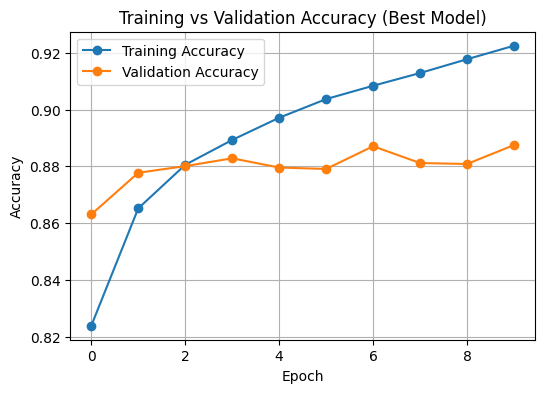

In [44]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')

plt.title("Training vs Validation Accuracy (Best Model)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## Discussion

The results demonstrate clear differences in how width and depth affect the performance and generalisation of multilayer perceptrons.

In terms of overall performance, the **Width-512 (2 layers)** model achieved the highest test accuracy (0.8792), suggesting that increasing width can significantly improve model performance. This supports the hypothesis that wider networks provide greater capacity to learn complex patterns from data. However, this model also required the longest training time (45.29 seconds), indicating a higher computational cost.

Among the depth-focused models, the **Depth-5 (128)** network achieved strong performance (0.8775 test accuracy), slightly below the widest model. This suggests that increasing depth also improves performance, but the gains are not substantially higher than those achieved by increasing width. The **Depth-3 (128)** model performed similarly, indicating that adding more layers beyond a certain point results in diminishing returns.

In terms of generalisation, the **Width-32 (2 layers)** model had the smallest generalisation gap (0.0253), meaning it generalised best to unseen data. However, this came at the cost of lower overall accuracy (0.8647). In contrast, larger models such as Width-512 showed higher accuracy but also larger generalisation gaps, suggesting a greater tendency to overfit.

Overall, both increasing width and depth improve performance, but width appears to provide slightly greater improvements in test accuracy. However, deeper networks offer competitive performance with lower computational cost. These findings highlight an important trade-off between model complexity, performance, generalisation, and training time.

The results also show that simply increasing model size does not always lead to better generalisation, reinforcing the importance of balancing model capacity with the risk of overfitting.

## Conclusion

This study investigated whether increasing the width or the depth of a multilayer perceptron has a greater effect on performance and generalisation.

The results indicate that increasing width generally leads to higher performance, as demonstrated by the Width-512 model achieving the highest test accuracy. However, this improvement comes with increased training time and a higher risk of overfitting. Increasing depth also improves performance, but the gains are more gradual and show diminishing returns beyond a certain number of layers.

In terms of generalisation, smaller models with fewer parameters tended to generalise better, although they achieved lower overall accuracy. This highlights the trade-off between model complexity and generalisation.

Overall, width appears to have a slightly stronger impact on performance, while depth provides a more computationally efficient alternative with comparable results. The findings suggest that the optimal architecture depends on the specific requirements of the task, including accuracy, generalisation, and computational constraints.

These results emphasise that increasing model size alone is not sufficient, and careful architectural design is required to achieve the best balance between performance and generalisation.

## Accessibility Notes

The following steps were taken to improve accessibility:

- Clear axis labels and plot titles were used
- Text explanations were added before each figure
- Grayscale sample images avoid misleading colour dependence
- Plots are interpretable without relying only on colour
- The notebook structure uses clear headings for screen-reader navigation

You can strengthen accessibility further by:
- adding alt-text if exporting to a webpage or PDF
- using subtitles if converting this into a video
- ensuring sufficient font size in exported figures

## References

Replace these with the exact sources you used.

Example references:

- Goodfellow, I., Bengio, Y. and Courville, A. (2016). *Deep Learning*. MIT Press.
- Chollet, F. (2021). *Deep Learning with Python*. Manning.
- LeCun, Y., Bottou, L., Bengio, Y. and Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), pp.2278–2324.
- Xiao, H., Rasul, K. and Vollgraf, R. (2017). Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms.
- TensorFlow Keras documentation.